# Big Mac Index

In this activity, you’ll make three API calls to Nasdaq to find the cost of a Big Mac in three countries.
 
Instructions:

1. In the `Unsolved` folder for this activity, create an environment file (`.env`). Enter your NASDAQ_API_KEY into this file.

2. In the Jupyter notebook, load the environment variables into your environment file by using the `load_dotenv()` function.

3. Get the Nasdaq API key from the environment variables, and store it in a Python variable named `nasdaq_api_key`. Then confirm that you successfully imported the API key by checking its type with the `type` function.

4. Create two variables named `start_date` and `end_date` to define the period that you want to get the Big Mac index for. For this activity, you can set both dates to `2020-07-31`.

5. Review the endpoint URLs that the starter notebook supplies. You’ll use these URLs to access the endpoints for the Big Mac index from three countries: the United States, Canada, and Mexico.

> **Hint** The Big Mac Index database from Nasdaq includes data from different countries. Each country's dataset has a Nasdaq code with the following format:  ECONOMIST/BIGMAC_{COUNTRY}. This activity uses USA, CAN, and MEX for the country codes.

6. Make the authenticated API request for each country by using the `request.get` function. Then print the response data by using the `json.dump` function. Analyze the data. Note that all the countries have the same output structure.

7. Review the output from the Big Mac Index for the United States. Identify the key-value pairs that define the response object. Determine how to get the `dollar_price` and `dollar_ppp` data elements. Use this information to create a DataFrame with the data of these indicators for the United States, Canada, and Mexico. The following image shows how your DataFrame should appear:

8. Use the DataFrame to create a bar chart that compares the `dollar_price` and the `dollar_ppp` of the United States, Canada, and Mexico.


Reference:

[Python requests function](https://pypi.org/project/requests/2.7.0/)

[json.dumps function](https://www.geeksforgeeks.org/json-dumps-in-python/)

[Nasdaq Big Mac Index Docs](https://data.nasdaq.com/data/ECONOMIST-The-Economist-Big-Mac-Index/documentation)

[Nasdaq Big Mac Index Usage](https://data.nasdaq.com/data/ECONOMIST-The-Economist-Big-Mac-Index/usage/quickstart/api)


## Import all required libraries and dependencies

In [1]:
import pandas as pd
import os
import json
import requests
from dotenv import load_dotenv

## Step 1: In the `Unsolved` folder for this activity, create an environment file (`.env`). Enter your NASDAQ_API_KEY into this file.

## Step 2: load the environment variables into your environment file by using the `load_dotenv()` function.

In [2]:
# Load .env enviroment variables into the notebook
load_dotenv()

True

## Step 3: Get the Nasdaq API key from the environment variables, and store it in a Python variable named `nasdaq_api_key`. Then confirm that you successfully imported the API key by checking its type with the `type` function.

In [3]:
# Get the API key from the environment variable and store as Python variable
finnhub_api_key = os.getenv("FINNHUB_API")

# Using the type funcion, confirm that the Nasdaq API key is available for use in the notebook
type(finnhub_api_key)

str

## Step 4: Create two variables named `start_date` and `end_date` to define the period that you want to get the Big Mac index for. For this activity, you can set both dates to `2020-07-31`.

In [ ]:
apple 

## Step 5: Review the endpoint URLs that the starter notebook supplies. You’ll use these URLs to access the endpoints for the Big Mac index from three countries: the United States, Canada, and Mexico.

In [8]:
apple = 'https://finnhub.io/api/v1/quote?symbol=AAPL&token=' + finnhub_api_key
tesla = 'https://finnhub.io/api/v1/quote?symbol=TSLA&token=' + finnhub_api_key
google = 'https://finnhub.io/api/v1/quote?symbol=GOOG&token=' + finnhub_api_key

## Step 6: Make the authenticated API request for each country by using the `request.get` function. Then print the response data by using the `json.dumps` function. Analyze the data. Note that all the countries have the same output structure.

In [6]:
response_apple = requests.get(apple).json()

In [7]:
print(json.dumps(response_apple, indent=2,sort_keys=True))

{
  "c": 250.14,
  "d": -5.62,
  "dp": -2.1974,
  "h": 256.33,
  "l": 249.55,
  "o": 255.48999999999998,
  "pc": 255.76,
  "t": 1773432000
}


In [9]:
response_tesla = requests.get(tesla).json()
print(json.dumps(response_tesla, indent=2, sort_keys=True))

{
  "c": 391.22,
  "d": -3.79,
  "dp": -0.9595,
  "h": 400.2,
  "l": 389.95,
  "o": 399.175,
  "pc": 395.01,
  "t": 1773432000
}


In [10]:
response_google = requests.get(google).json()
print(json.dumps(response_google,indent=2,sort_keys=True))

{
  "c": 301.48,
  "d": -1.73,
  "dp": -0.5706,
  "h": 307.26,
  "l": 299.7801,
  "o": 306.66499999999996,
  "pc": 303.21,
  "t": 1773432000
}


## Step 7: Review the output from the Big Mac Index for the United States. Identify the key-value pairs that define the response object. Determine how to get the `dollar_price` and `dollar_ppp` data elements. Use this information to create a DataFrame with the data of these indicators for the United States, Canada, and Mexico. 

In [14]:
stock_data = {
    'current_price': [
        response_apple['c'],
        response_tesla['c'],
        response_google['c']
    ],
    'percent_change': [
        response_apple['dp'],
        response_tesla['dp'],
        response_google['dp']
    ],
    'high_price': [
        response_apple['h'],
        response_tesla['h'],
        response_google['h']
    ],
    'low_price': [
        response_apple['l'],
        response_tesla['l'],
        response_google['l']
    ]
}

In [15]:
stock_data_df = pd.DataFrame(stock_data, index=['APPLE','TESLA','GOOGLE'])
stock_data_df

,current_price,percent_change,high_price,low_price
APPLE,250.14,-2.1974,256.33,249.5500
TESLA,391.22,-0.9595,400.20,389.9500
GOOGLE,301.48,-0.5706,307.26,299.7801


### Step 8: Use the DataFrame to create a bar chart that compares the `dollar_price` and the `dollar_ppp` of the United States, Canada, and Mexico.

<Axes: title={'center': 'Stock Price - Apple, Tesla, Google'}>

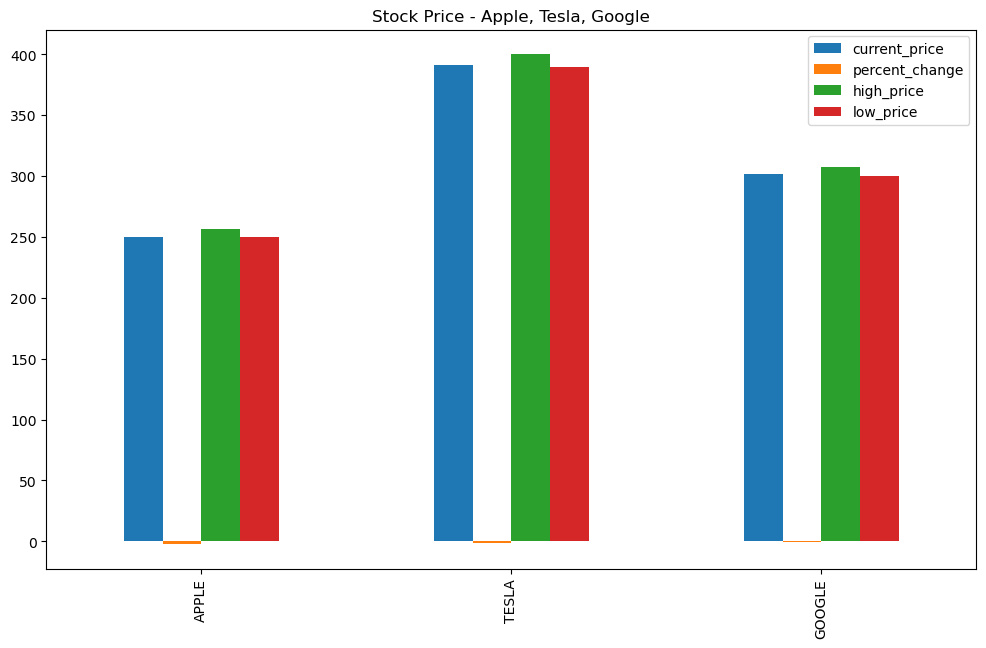

In [28]:
stock_data_df.plot.bar(figsize=(12,7), title='Stock Price - Apple, Tesla, Google')

#### `params` use a python dictionary to handle SQL query  

In [18]:
# apple = 'https://finnhub.io/api/v1/quote?symbol=AAPL&token=' + finnhub_api_key
# tesla = 'https://finnhub.io/api/v1/quote?symbol=TSLA&token=' + finnhub_api_key
# google = 'https://finnhub.io/api/v1/quote?symbol=GOOG&token=' + finnhub_api_key
myurl = "https://finnhub.io/api/v1/quote?"
mydict = {"symbol": "AAPL", "token": finnhub_api_key}

requests.get(myurl, params = mydict).json()

{'c': 250.14,
 'd': -5.62,
 'dp': -2.1974,
 'h': 256.33,
 'l': 249.55,
 'o': 255.48999999999998,
 'pc': 255.76,
 't': 1773432000}

In [21]:
if (requests.get(myurl, params = mydict).status_code == 200) :
    print("now get the info I want")
else:
    print("be careful here")

now get the info I want


In [25]:
requests.get("http://www.hailotabc253cc.com", params = mydict).status_code

ConnectionError: HTTPConnectionPool(host='www.hailotabc253cc.com', port=80): Max retries exceeded with url: /?symbol=AAPL&token=cshqu7pr01qg5bus068gcshqu7pr01qg5bus0690 (Caused by NameResolutionError("HTTPConnection(host='www.hailotabc253cc.com', port=80): Failed to resolve 'www.hailotabc253cc.com' ([Errno 8] nodename nor servname provided, or not known)"))